# Lab 1 - Les Bases de la Data Science en Python

**Navigation** : [Index](../../README.md) | [Suivant >>](../../Day2/Labs/Lab2-RFP-Analysis/Lab2-RFP-Analysis.ipynb)

## Objectifs d'apprentissage

A la fin de ce laboratoire, vous saurez :
1. Charger et manipuler des données avec Pandas
2. Explorer un DataFrame (info, describe, head)
3. Filtrer et sélectionner des données avec des conditions
4. Visualiser des données avec Matplotlib
5. Entraîner un modèle de régression linéaire simple

### Prérequis
- Python 3.10+
- Bibliothèques : pandas, matplotlib, scikit-learn
- Aucune expérience préalable en Data Science requise

### Durée estimée : 30-40 minutes

## Introduction à Pandas

Pandas est une bibliothèque essentielle pour la manipulation de données en Python. Elle introduit la notion de DataFrame, une structure de données tabulaire puissante.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Créer un DataFrame avec un dataset réaliste de ventes
np.random.seed(42)  # Pour reproductibilité

# Générer 60 jours de données de ventes
n_days = 60
start_date = datetime(2024, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(n_days)]

# Produits avec prix et catégories
produits = {
    'Widget A': {'prix_base': 150, 'categorie': 'Electronique'},
    'Widget B': {'prix_base': 80, 'categorie': 'Electronique'},
    'Gadget X': {'prix_base': 45, 'categorie': 'Accessoires'},
    'Gadget Y': {'prix_base': 30, 'categorie': 'Accessoires'},
    'Module Z': {'prix_base': 200, 'categorie': 'Premium'}
}

# Générer les transactions
data = []
for date in dates:
    for produit, info in produits.items():
        # Variation saisonnière + bruit aléatoire
        saison = 1 + 0.3 * np.sin(2 * np.pi * date.timetuple().tm_yday / 365)
        ventes = int(info['prix_base'] * saison * (0.8 + 0.4 * np.random.random()))
        data.append({
            'Date': date.strftime('%Y-%m-%d'),
            'Produit': produit,
            'Categorie': info['categorie'],
            'Prix_Unitaire': info['prix_base'],
            'Ventes': ventes
        })

df = pd.DataFrame(data)

# Créer aussi un DataFrame simple pour la démonstration
df_simple = pd.DataFrame({'col1': [1, 2], 'col2': [3, 4]})

print("DataFrame simple :")
print(df_simple)
print(f"\nDataset de ventes : {len(df)} enregistrements sur {n_days} jours")
print(f"Produits : {df['Produit'].nunique()} | Catégories : {df['Categorie'].nunique()}")
print("\nAperçu des données :")
df.head(10)

DataFrame simple :
   col1  col2
0     1     3
1     2     4

Dataset de ventes : 300 enregistrements sur 60 jours
Produits : 5 | Catégories : 3

Aperçu des données :


,Date,Produit,Categorie,Prix_Unitaire,Ventes
0,2024-01-01,Widget A,Electronique,150,143
1,2024-01-01,Widget B,Electronique,80,94
2,2024-01-01,Gadget X,Accessoires,45,49
3,2024-01-01,Gadget Y,Accessoires,30,31
4,2024-01-01,Module Z,Premium,200,173
5,2024-01-02,Widget A,Electronique,150,130
6,2024-01-02,Widget B,Electronique,80,66
7,2024-01-02,Gadget X,Accessoires,45,52
8,2024-01-02,Gadget Y,Accessoires,30,31
9,2024-01-02,Module Z,Premium,200,218


## Exploration de Données

Une fois les données chargées, les premières étapes consistent à les explorer pour comprendre leur structure et leur contenu.

In [2]:
# Afficher les premières lignes
print("Premières lignes (head) :")
print(df.head())

# Obtenir des informations générales sur le DataFrame
print("\nInformations (info) :")
df.info()

# Obtenir des statistiques descriptives
print("\nStatistiques descriptives (describe) :")
print(df.describe())

# Statistiques par catégorie
print("\nVentes moyennes par catégorie :")
print(df.groupby('Categorie')['Ventes'].mean().round(2))

Premières lignes (head) :
         Date   Produit     Categorie  Prix_Unitaire  Ventes
0  2024-01-01  Widget A  Electronique            150     143
1  2024-01-01  Widget B  Electronique             80      94
2  2024-01-01  Gadget X   Accessoires             45      49
3  2024-01-01  Gadget Y   Accessoires             30      31
4  2024-01-01  Module Z       Premium            200     173

Informations (info) :
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Date           300 non-null    str  
 1   Produit        300 non-null    str  
 2   Categorie      300 non-null    str  
 3   Prix_Unitaire  300 non-null    int64
 4   Ventes         300 non-null    int64
dtypes: int64(2), str(3)
memory usage: 20.2 KB

Statistiques descriptives (describe) :
       Prix_Unitaire      Ventes
count     300.000000  300.000000
mean      101.000000  114.370000
std        6

## Sélection et Filtrage

Apprenons à sélectionner des colonnes spécifiques et à filtrer les lignes en fonction de conditions.

In [3]:
# Sélectionner une seule colonne
produits = df['Produit']
print("Colonne 'Produit' (5 premiers) :")
print(produits.head())

# Filtrer les lignes où les ventes sont supérieures à 100
ventes_elevees = df[df['Ventes'] > 100]
print(f"\nVentes supérieures à 100 : {len(ventes_elevees)} enregistrements")
print(ventes_elevees.head())

# Filtrer par catégorie
electronique = df[df['Categorie'] == 'Electronique']
print(f"\nProduits Electronique : {len(electronique)} enregistrements")
print(electronique[['Date', 'Produit', 'Ventes']].head())

Colonne 'Produit' (5 premiers) :
0    Widget A
1    Widget B
2    Gadget X
3    Gadget Y
4    Module Z
Name: Produit, dtype: str

Ventes supérieures à 100 : 135 enregistrements
          Date   Produit     Categorie  Prix_Unitaire  Ventes
0   2024-01-01  Widget A  Electronique            150     143
4   2024-01-01  Module Z       Premium            200     173
5   2024-01-02  Widget A  Electronique            150     130
9   2024-01-02  Module Z       Premium            200     218
10  2024-01-03  Widget A  Electronique            150     123

Produits Electronique : 120 enregistrements
          Date   Produit  Ventes
0   2024-01-01  Widget A     143
1   2024-01-01  Widget B      94
5   2024-01-02  Widget A     130
6   2024-01-02  Widget B      66
10  2024-01-03  Widget A     123


## Visualisation de Données

La visualisation est cruciale pour comprendre les tendances. Nous utiliserons Matplotlib pour créer un graphique simple.

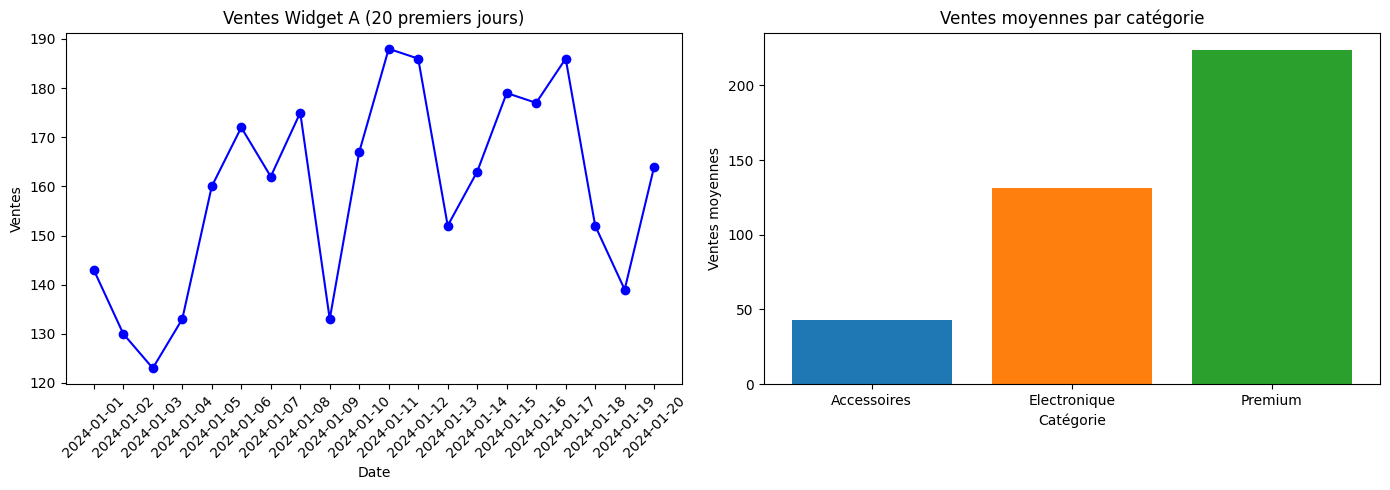

In [4]:
import matplotlib.pyplot as plt

# Graphique 1 : Ventes par date (échantillon)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventes par date pour Widget A
widget_a = df[df['Produit'] == 'Widget A']
axes[0].plot(widget_a['Date'].values[:20], widget_a['Ventes'].values[:20], 'b-o')
axes[0].set_title('Ventes Widget A (20 premiers jours)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Ventes')
axes[0].tick_params(axis='x', rotation=45)

# Ventes moyennes par catégorie
ventes_cat = df.groupby('Categorie')['Ventes'].mean()
axes[1].bar(ventes_cat.index, ventes_cat.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Ventes moyennes par catégorie')
axes[1].set_xlabel('Catégorie')
axes[1].set_ylabel('Ventes moyennes')

plt.tight_layout()
plt.show()

## Introduction au Machine Learning

Le Machine Learning consiste à entraîner un 'modèle' sur des données pour qu'il puisse faire des 'prédictions' sur de nouvelles données. C'est un concept clé de l'IA. Ici, nous allons simuler une prédiction très simple.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Préparer les données pour le ML
# Convertir la date en jour de l'année (feature numérique)
df['Jour'] = pd.to_datetime(df['Date']).dt.dayofyear

# Filtrer un seul produit pour la démonstration
widget_a = df[df['Produit'] == 'Widget A'].copy()

X = widget_a[['Jour']].values  # Feature : jour de l'année
y = widget_a['Ventes'].values  # Target : ventes

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer et entraîner le modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions sur le test set
y_pred = model.predict(X_test)

# Évaluer le modèle
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Performance du modèle :")
print(f"  R² Score : {r2:.3f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  Coefficient : {model.coef_[0]:.4f}")
print(f"  Intercept : {model.intercept_:.2f}")

# Prédire les ventes pour un jour futur
jour_futur = 90  # 31 mars
prediction = model.predict([[jour_futur]])
print(f"\nPrédiction des ventes pour le jour {jour_futur} : {prediction[0]:.2f}")

Performance du modèle :
  R² Score : 0.229
  RMSE : 20.66
  Coefficient : 0.7251
  Intercept : 148.96

Prédiction des ventes pour le jour 90 : 214.22


## 🎯 Exercices Pratiques

### Exercice 1 : Calcul de statistiques par produit

À partir du DataFrame `df`, calculez et affichez :
1. Le total des ventes pour chaque produit (Widget A et Widget B)
2. La moyenne des ventes par produit
3. Le jour avec les ventes les plus élevées pour chaque produit

**Indices** : Utilisez `groupby()` et les fonctions d'agrégation de Pandas.

In [6]:
# Votre code pour l'Exercice 1

# TODO: Calculez le total des ventes par produit
total_ventes_produit = None  # Utilisez groupby('Produit')['Ventes'].sum()

# TODO: Calculez la moyenne des ventes par produit
moyenne_ventes_produit = None  # Utilisez groupby('Produit')['Ventes'].mean()

# TODO: Trouvez le jour avec les ventes les plus élevées pour chaque produit
# Indice: Utilisez sort_values() puis drop_duplicates()
jour_max_ventes = None

# Affichage des résultats
print("Total des ventes par produit :")
print(total_ventes_produit)
print("\nMoyenne des ventes par produit :")
print(moyenne_ventes_produit)
print("\nJour avec ventes maximales par produit :")
print(jour_max_ventes)

Total des ventes par produit :
None

Moyenne des ventes par produit :
None

Jour avec ventes maximales par produit :
None


# Votre code pour l'Exercice 2

# TODO: Calculez la moyenne globale des ventes
moyenne_globale = None  # Utilisez df["Ventes"].mean()

# TODO: Créez le DataFrame filtré avec les deux conditions
# Conditions: Ventes > moyenne_globale ET Categorie == "Electronique"
df_filtre = None  # Utilisez des parenthèses pour chaque condition

# Affichage du résultat
if moyenne_globale is not None and df_filtre is not None:
    print(f"Moyenne globale des ventes : {moyenne_globale:.2f}")
    print(f"Nombre d enregistrements filtrés : {len(df_filtre)}")
    print("DataFrame filtré (Electronique avec ventes > moyenne) :")
    print(df_filtre.head())
else:
    print("Exercice à compléter : calculez la moyenne et filtrez le DataFrame")


In [7]:
# Votre code pour l'Exercice 3

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# TODO: Créez deux DataFrames, un pour chaque produit (Widget A et Gadget X)
df_widget_a = None  # Filtrez df où Produit == "Widget A"
df_gadget_x = None  # Filtrez df où Produit == "Gadget X"

# TODO: Préparez les features (X = Jour) et target (y = Ventes) pour Widget A
X_a = None  # df_widget_a[["Jour"]].values
y_a = None  # df_widget_a["Ventes"].values

# TODO: Préparez les features et target pour Gadget X
X_x = None
y_x = None

# TODO: Entraînez un modèle pour chaque produit
model_a = LinearRegression()
model_x = LinearRegression()

# Appelez model.fit(X, y) pour chaque modèle

# TODO: Prédisez les ventes pour le jour 90 (31 mars)
prediction_a = None  # model_a.predict([[90]])[0]
prediction_x = None

# Affichage des résultats
if prediction_a is not None and prediction_x is not None:
    print(f"Prédiction jour 90 - Widget A : {prediction_a:.2f}")
    print(f"Prédiction jour 90 - Gadget X : {prediction_x:.2f}")
    print(f"Différence de prédictions : {abs(prediction_a - prediction_x):.2f}")
else:
    print("Exercice à compléter : filtrez les DataFrames et entraînez les modèles")


Exercice à compléter : filtrez les DataFrames et entraînez les modèles


### Exercice 3 : Prédictions pour chaque produit

Entraînez un modèle de régression linéaire **séparé** pour chaque produit (Widget A et Widget B), puis prédisez les ventes pour le jour 7 de chacun.

**Indices** : Filtrez le DataFrame par produit avant d'entraîner le modèle.

In [8]:
# Votre code pour l'Exercice 3

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# TODO: Créez deux DataFrames, un pour chaque produit (Widget A et Gadget X)
df_widget_a = None  # Filtrez df où Produit == "Widget A"
df_gadget_x = None  # Filtrez df où Produit == "Gadget X"

# TODO: Préparez les features (X = Jour) et target (y = Ventes) pour Widget A
X_a = None  # df_widget_a[["Jour"]].values
y_a = None  # df_widget_a["Ventes"].values

# TODO: Préparez les features et target pour Gadget X
X_x = None
y_x = None

# TODO: Entraînez un modèle pour chaque produit
model_a = LinearRegression()
model_x = LinearRegression()

# Appelez model.fit(X, y) pour chaque modèle

# TODO: Prédisez les ventes pour le jour 90 (31 mars)
prediction_a = None  # model_a.predict([[90]])[0]
prediction_x = None

# Affichage des résultats
if prediction_a is not None and prediction_x is not None:
    print(f"Prédiction jour 90 - Widget A : {prediction_a:.2f}")
    print(f"Prédiction jour 90 - Gadget X : {prediction_x:.2f}")
    print(f"Différence de prédictions : {abs(prediction_a - prediction_x):.2f}")
else:
    print("Exercice à compléter : filtrez les DataFrames et entraînez les modèles")


Exercice à compléter : filtrez les DataFrames et entraînez les modèles


## Conclusion : De la Data aux Agents IA

Félicitations ! Vous avez exploré les briques fondamentales de la Data Science en Python : charger et manipuler des données avec Pandas, les visualiser, et même faire une prédiction simple avec un modèle de Machine Learning.

Ces briques (le **DataFrame** comme source de connaissance, le **Modèle** comme outil de raisonnement) sont exactement ce que nous allons apprendre à fournir à des **Agents d'IA**.

Dans la suite de ce cursus, nous verrons comment un agent peut :
1.  Recevoir un **Prompt** en langage naturel (ex: "Donne-moi le total des ventes pour le Widget A").
2.  Utiliser le DataFrame comme un outil via une **API** pour trouver la réponse.
3.  Utiliser un Modèle de ML pour répondre à des questions plus complexes (ex: "Quelle serait la prévision des ventes pour demain ?").

Ce laboratoire constitue la base technique essentielle pour construire des systèmes d'IA plus autonomes et intelligents.

---

**Navigation** : [Index](../../README.md) | [Suivant >> Lab 2 - RFP Analysis](../../Day2/Labs/Lab2-RFP-Analysis/Lab2-RFP-Analysis.ipynb)